In [1]:
# ============================================================
# LOAD VERIFIED DATASET
# ============================================================

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from scipy.stats import pearsonr, linregress
import pymannkendall as mk

# ============================================================
# FILE PATH
# ============================================================

PROJECT = r"C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2"

NOTEBOOK = os.path.join(PROJECT, "Notebook")

FILE = os.path.join(
    NOTEBOOK,
    "Arctic_SeaIce_Albedo_Trend_Analysis_2000_2025.xlsx"
)

# ============================================================
# READ ANNUAL STATISTICS
# ============================================================

df = pd.read_excel(
    FILE,
    sheet_name="06_Annual_Statistics"
)

print(df.head())

print(df.columns.tolist())

   Year  Sea Ice Area (Million km²)  Ocean Mean Albedo  Sea Ice Deviation (%)  \
0  2000                      10.303             0.4890               7.163631   
1  2001                      10.462             0.4980               8.817423   
2  2002                      10.103             0.4835               5.083390   
3  2003                      10.244             0.4770               6.549960   
4  2004                      10.073             0.4933               4.771353   

   Albedo Deviation (%)  
0              6.834052  
1              8.800323  
2              5.632442  
3              4.212357  
4              7.773492  
['Year', 'Sea Ice Area (Million km²)', 'Ocean Mean Albedo', 'Sea Ice Deviation (%)', 'Albedo Deviation (%)']


In [31]:
# ============================================================
# PUBLICATION QUALITY FUNCTION
# Interannual Variation of Arctic Sea Ice Area
# and Ocean Mean Albedo
# ============================================================

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.stats import pearsonr
from scipy.stats import linregress

import pymannkendall as mk


# ============================================================
# FUNCTION
# ============================================================

def plot_trend(
    start_year,
    end_year,
    output_name
):

    # ========================================================
    # FILTER DATA
    # ========================================================

    df_plot = df[
        (df["Year"] >= start_year) &
        (df["Year"] <= end_year)
    ].copy()

    if len(df_plot) < 3:
        raise ValueError(
            "Not enough years for trend analysis."
        )

    # ========================================================
    # VARIABLES
    # ========================================================

    years = df_plot["Year"]

    sea = df_plot["Sea Ice Deviation (%)"]

    alb = df_plot["Albedo Deviation (%)"]

    # ========================================================
    # PEARSON CORRELATION
    # ========================================================

    r, p_corr = pearsonr(
    sea,
    alb
)

    # ========================================================
    # MANN KENDALL
    # ========================================================

    sea_result = mk.original_test(sea)

    alb_result = mk.original_test(alb)

    # ========================================================
    # LINEAR REGRESSION
    # ========================================================

    sea_lr = linregress(
        years,
        sea
    )

    alb_lr = linregress(
        years,
        alb
    )

    # ========================================================
    # SEN TREND LINE
    # ========================================================

    # sea_sen = (

    #     sea_result.intercept

    #     +

    #     sea_result.slope * years

    # )

    # alb_sen = (

    #     alb_result.intercept

    #     +

    #     alb_result.slope * years

    # )

    index = np.arange(len(df_plot))

    sea_sen = (
    sea_result.intercept +
    sea_result.slope * index
)

    alb_sen = (
    alb_result.intercept +
    alb_result.slope * index
)

    # ========================================================
    # FIGURE
    # ========================================================

    plt.rcParams["font.family"] = "Arial"

    fig, ax1 = plt.subplots(
        figsize=(16,8)
    )

    # ========================================================
    # SEA ICE
    # ========================================================

    ax1.plot(

        years,

        sea,

        color="#1565C0",

        marker="o",

        linewidth=2.8,

        markersize=7,

        label="Sea Ice Deviation"

    )

    ax1.plot(

        years,

        sea_sen,

        "--",

        color="#1565C0",

        linewidth=2.4,

        label="Sea Ice Sen's Trend"

    )

    ax1.set_ylabel(

        "Sea Ice Deviation (%)",

        fontsize=15,

        color="#1565C0",

        fontweight="bold"

    )

    ax1.tick_params(

        axis="y",

        colors="#1565C0"

    )

    # ========================================================
    # ZERO LINE
    # ========================================================

    ax1.axhline(

        0,

        color="black",

        linewidth=1.1

    )

    # ========================================================
    # SECOND AXIS
    # ========================================================

    ax2 = ax1.twinx()
        # ========================================================
    # OCEAN MEAN ALBEDO
    # ========================================================

    ax2.plot(

        years,

        alb,

        color="#C62828",

        marker="s",

        linewidth=2.8,

        markersize=7,

        label="Albedo Deviation"

    )

    ax2.plot(

        years,

        alb_sen,

        "--",

        color="#C62828",

        linewidth=2.4,

        label="Albedo Sen's Trend"

    )

    ax2.set_ylabel(

        "Ocean Mean Albedo Deviation (%)",

        fontsize=15,

        color="#C62828",

        fontweight="bold"

    )

    ax2.tick_params(

        axis="y",

        colors="#C62828"

    )

    # ========================================================
    # GRID
    # ========================================================

    ax1.grid(

        True,

        linestyle="--",

        alpha=0.35

    )

    # ========================================================
    # X LABEL
    # ========================================================

    ax1.set_xlabel(

        "Year",

        fontsize=15,

        fontweight="bold"

    )

    # ========================================================
    # TITLE
    # ========================================================

    plt.title(

        f"Interannual Variation of Arctic Sea Ice Area and Ocean Mean Albedo\n"
        f"({start_year}–{end_year})",

        fontsize=18,

        fontweight="bold"

    )

    # ========================================================
    # SEA ICE INFORMATION BOX
    # ========================================================

    sea_p = (
        "<0.001"
        if sea_result.p < 0.001
        else f"{sea_result.p:.4f}"
    )

    ax1.text(

        0.985,

        0.76,

        (
            "Sea Ice\n"
            f"Trend : {sea_result.trend}\n"
            f"Sen's Slope : {sea_result.slope:.3f}\n"
            f"Tau : {sea_result.Tau:.3f}\n"
            f"p-value : {sea_p}"
        ),

        transform=ax1.transAxes,

        fontsize=10,

        ha="right",

        va="top",

        bbox=dict(

            facecolor="white",

            edgecolor="#1565C0",

            boxstyle="round,pad=0.5",

            linewidth=1.5

        )

    )

    # ========================================================
    # ALBEDO INFORMATION BOX
    # ========================================================

    alb_p = (
        "<0.001"
        if alb_result.p < 0.001
        else f"{alb_result.p:.4f}"
    )

    ax2.text(

        0.73,

        # 0.76,
        0.10,

        (
            "Albedo\n"
            f"Trend : {alb_result.trend}\n"
            f"Sen's Slope : {alb_result.slope:.3f}\n"
            f"Tau : {alb_result.Tau:.3f}\n"
            f"p-value : {alb_p}"
        ),

        transform=ax2.transAxes,

        fontsize=10,

        ha="right",

        va="top",

        bbox=dict(

            facecolor="white",

            edgecolor="#C62828",

            boxstyle="round,pad=0.5",

            linewidth=1.5

        )

    )

    # ========================================================
    # PEARSON CORRELATION BOX
    # ========================================================

    corr_p = (
        "<0.001"
        if p_corr < 0.001
        else f"{p_corr:.4f}"
    )

    ax1.text(

        0.02,

        0.05,

        (
            f"Pearson r = {r:.3f}\n"
            f"p-value = {corr_p}"
        ),

        transform=ax1.transAxes,

        fontsize=11,

        bbox=dict(

            facecolor="white",

            edgecolor="black",

            boxstyle="round,pad=0.5"

        )

    )

    # ========================================================
    # LEGEND
    # ========================================================

    lines1, labels1 = ax1.get_legend_handles_labels()

    lines2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(

        lines1 + lines2,

        labels1 + labels2,

        loc="upper right",

        bbox_to_anchor=(0.99, 0.995),

        fontsize=11,

        frameon=True,

        fancybox=True,

        framealpha=0.95

    )

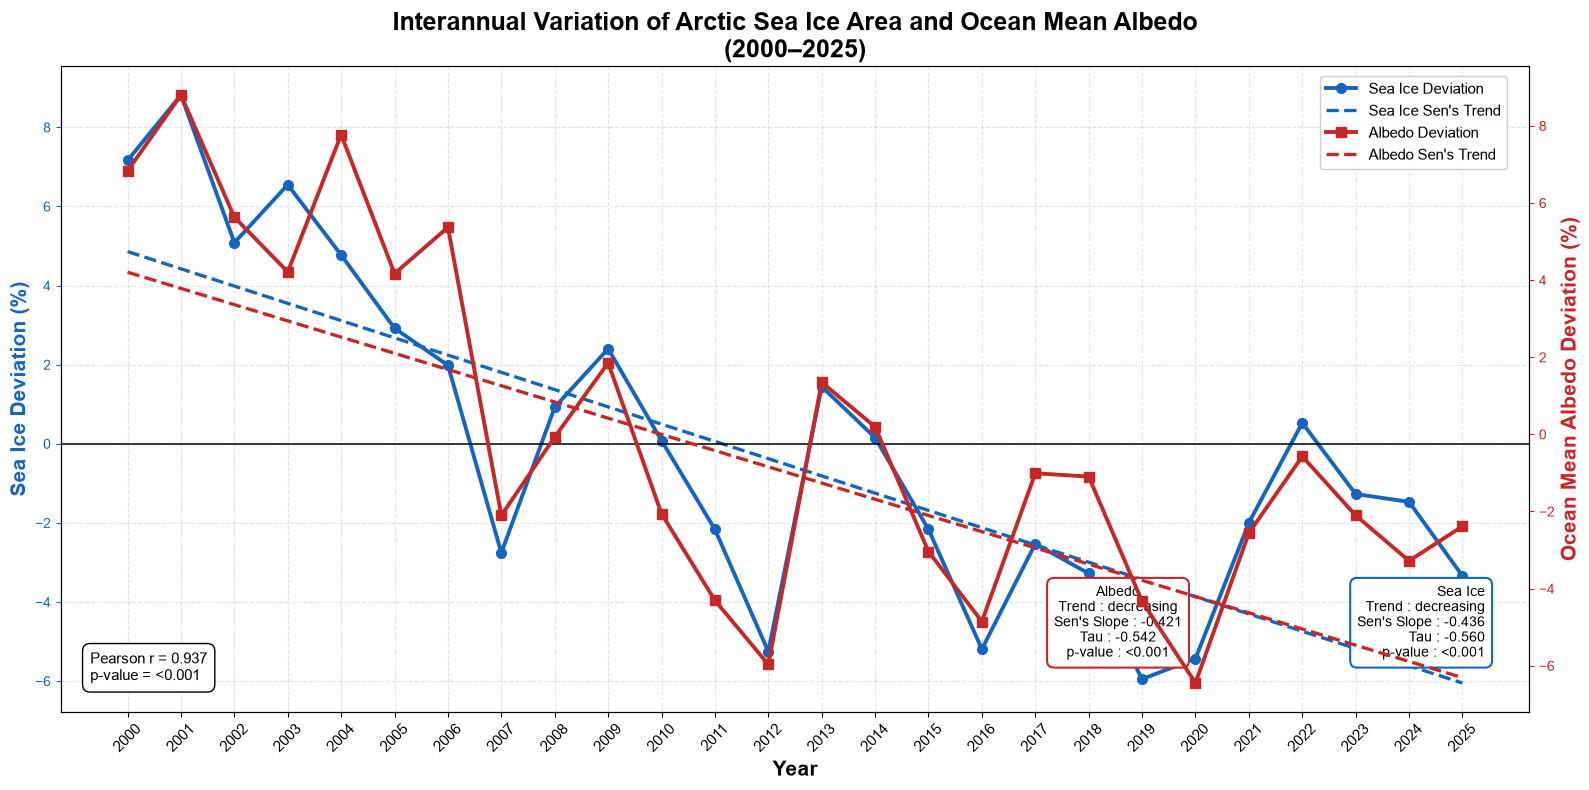


2000 - 2025
Pearson r : 0.9372
Pearson p : 0.000000

Sea Ice
Mann_Kendall_Test(trend='decreasing', h=np.True_, p=np.float64(6.593688664424668e-05), z=np.float64(-3.990490153550879), Tau=np.float64(-0.56), s=np.float64(-182.0), var_s=np.float64(2057.3333333333335), slope=np.float64(-0.4363553791287409), intercept=np.float64(4.858773141493935))

Ocean Mean Albedo
Mann_Kendall_Test(trend='decreasing', h=np.True_, p=np.float64(0.00011422109125835966), z=np.float64(-3.8582087119967063), Tau=np.float64(-0.5415384615384615), s=np.float64(-176.0), var_s=np.float64(2057.3333333333335), slope=np.float64(-0.4205634962649255), intercept=np.float64(4.204164460914074))

Saved Successfully
C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2\Results\Interannual_SeaIce_Albedo_2000_2025.png
C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2\Results\Interannual_SeaIce_Albedo_2000_2025.pdf


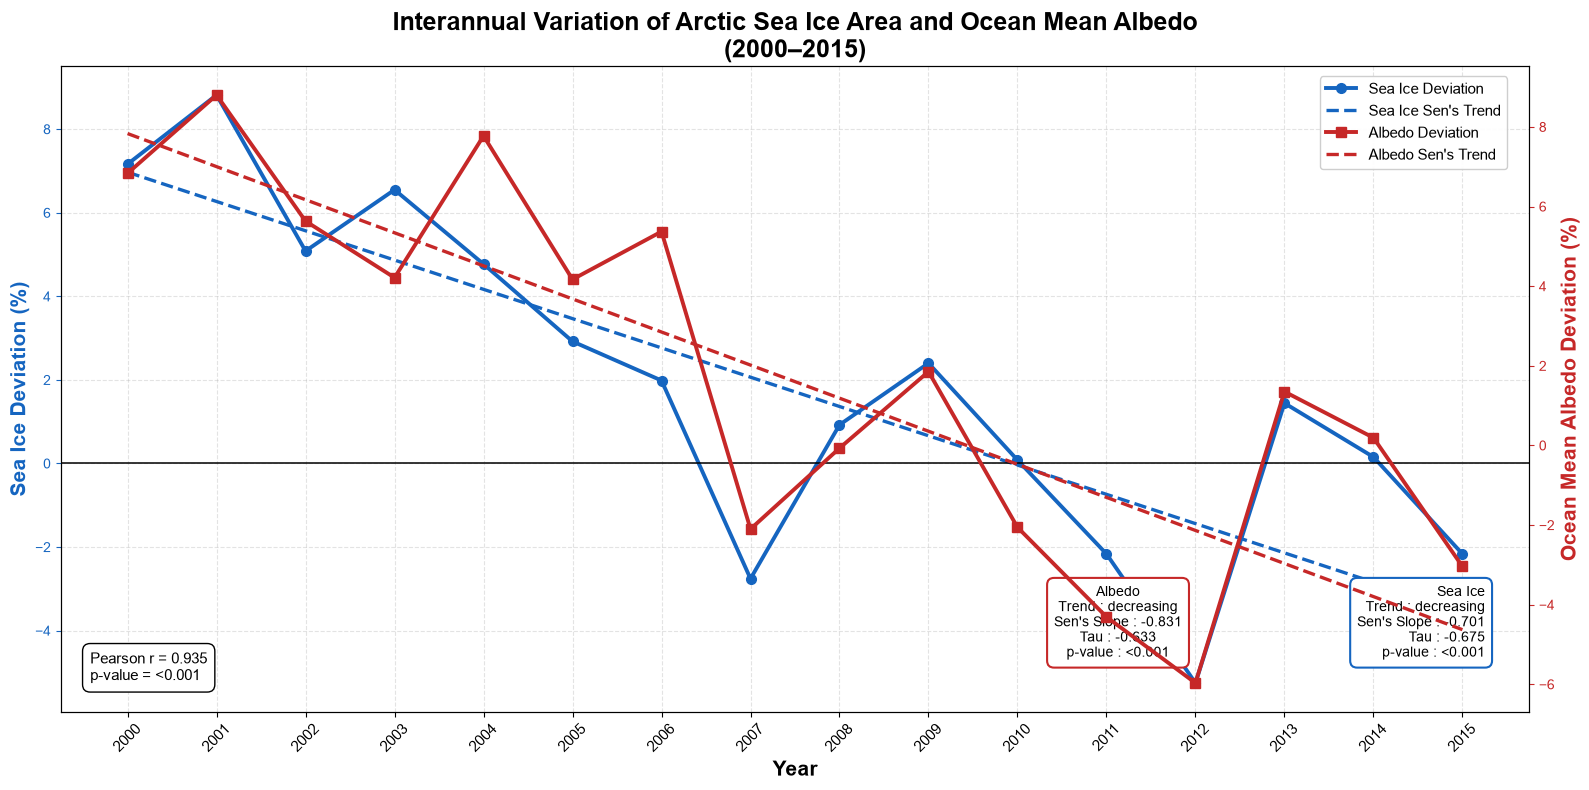


2000 - 2015
Pearson r : 0.9350
Pearson p : 0.000000

Sea Ice
Mann_Kendall_Test(trend='decreasing', h=np.True_, p=np.float64(0.0003116036246229026), z=np.float64(-3.605457384567121), Tau=np.float64(-0.675), s=np.float64(-81.0), var_s=np.float64(492.3333333333333), slope=np.float64(-0.7008679673508801), intercept=np.float64(6.969908509387086))

Ocean Mean Albedo
Mann_Kendall_Test(trend='decreasing', h=np.True_, p=np.float64(0.0007336401211037735), z=np.float64(-3.3766887666806116), Tau=np.float64(-0.6333333333333333), s=np.float64(-76.0), var_s=493.3333333333333, slope=np.float64(-0.8307234428386974), intercept=np.float64(7.832012282590837))

Saved Successfully
C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2\Results\Interannual_SeaIce_Albedo_2000_2015.png
C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2\Results\Interannual_SeaIce_Albedo_2000_2015.pdf


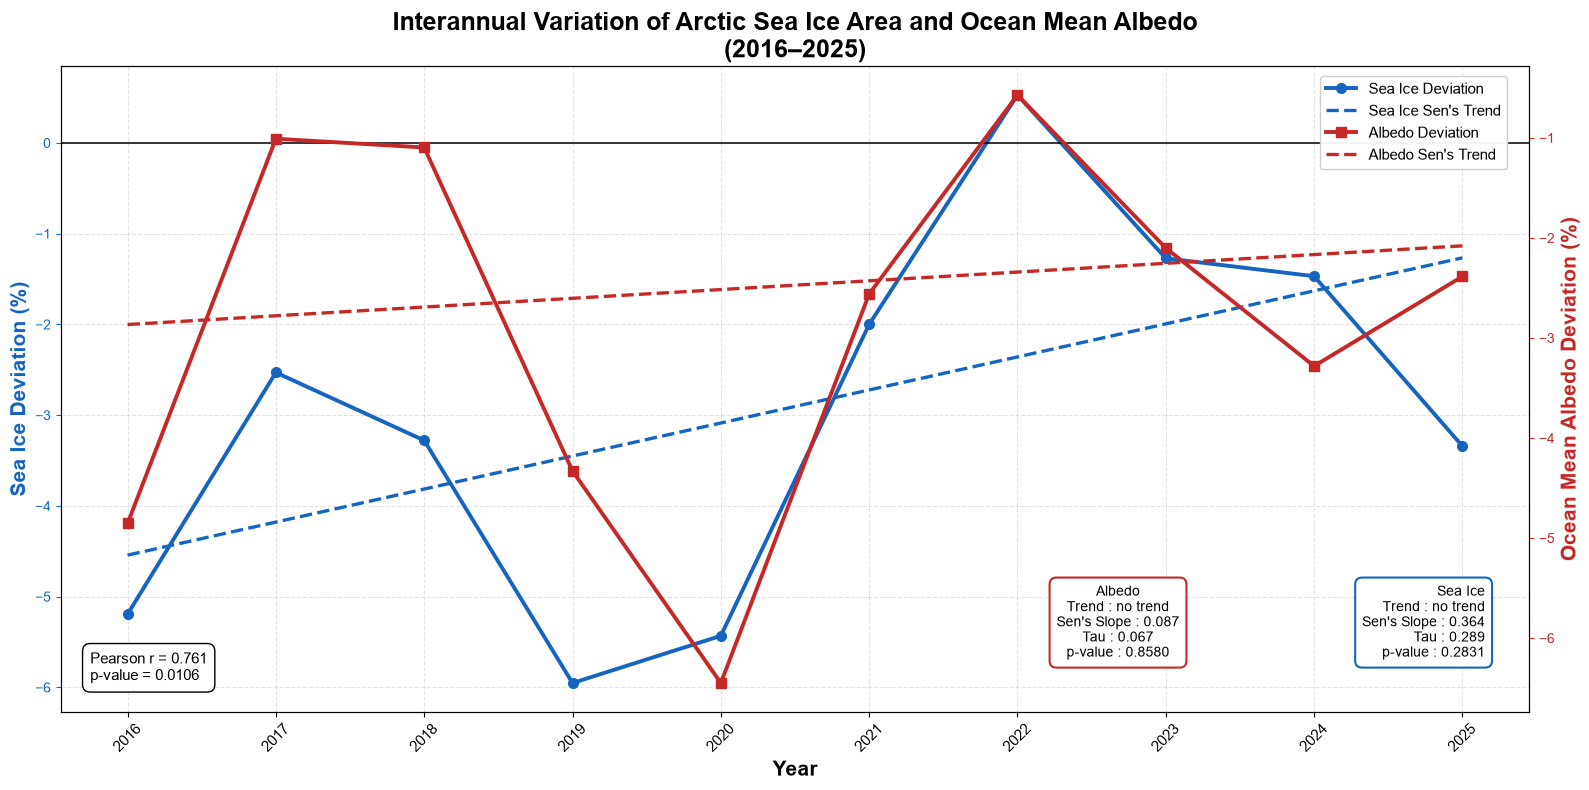


2016 - 2025
Pearson r : 0.7609
Pearson p : 0.010583

Sea Ice
Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.28313087066234655), z=np.float64(1.073312629199899), Tau=np.float64(0.28888888888888886), s=np.float64(13.0), var_s=125.0, slope=np.float64(0.364042228898554), intercept=np.float64(-4.54292697952964))

Ocean Mean Albedo
Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.8580276569875211), z=np.float64(0.17888543819998318), Tau=np.float64(0.06666666666666667), s=np.float64(3.0), var_s=125.0, slope=np.float64(0.087389817405699), intercept=np.float64(-2.866217953565747))

Saved Successfully
C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2\Results\Interannual_SeaIce_Albedo_2016_2025.png
C:\Users\ACER\OneDrive\Desktop\ISRO\Snow_2\Results\Interannual_SeaIce_Albedo_2016_2025.pdf

ALL FIGURES CREATED SUCCESSFULLY


In [34]:
# ============================================================
# PUBLICATION QUALITY FUNCTION
# Interannual Variation of Arctic Sea Ice Area
# and Ocean Mean Albedo
# ============================================================

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.stats import pearsonr
from scipy.stats import linregress

import pymannkendall as mk


# ============================================================
# FUNCTION
# ============================================================

def plot_trend(
    start_year,
    end_year,
    output_name
):

    # ========================================================
    # FILTER DATA
    # ========================================================

    df_plot = df[
        (df["Year"] >= start_year) &
        (df["Year"] <= end_year)
    ].copy()

    if len(df_plot) < 3:
        raise ValueError(
            "Not enough years for trend analysis."
        )

    # ========================================================
    # VARIABLES
    # ========================================================

    years = df_plot["Year"]

    sea = df_plot["Sea Ice Deviation (%)"]

    alb = df_plot["Albedo Deviation (%)"]

    # ========================================================
    # PEARSON CORRELATION
    # ========================================================

    r, p_corr = pearsonr(
    sea,
    alb
)

    # ========================================================
    # MANN KENDALL
    # ========================================================

    sea_result = mk.original_test(sea)

    alb_result = mk.original_test(alb)

    # ========================================================
    # LINEAR REGRESSION
    # ========================================================

    sea_lr = linregress(
        years,
        sea
    )

    alb_lr = linregress(
        years,
        alb
    )

    # ========================================================
    # SEN TREND LINE
    # ========================================================

    index = np.arange(len(df_plot))

    sea_sen = (
    sea_result.intercept +
    sea_result.slope * index
)

    alb_sen = (
    alb_result.intercept +
    alb_result.slope * index
)

    # ========================================================
    # FIGURE
    # ========================================================

    plt.rcParams["font.family"] = "Arial"

    fig, ax1 = plt.subplots(
    figsize=(16,8)
)

    # ========================================================
    # SEA ICE
    # ========================================================

    ax1.plot(

        years,

        sea,

        color="#1565C0",

        marker="o",

        linewidth=2.8,

        markersize=7,

        label="Sea Ice Deviation"

    )

    ax1.plot(

        years,

        sea_sen,

        "--",

        color="#1565C0",

        linewidth=2.4,

        label="Sea Ice Sen's Trend"

    )

    ax1.set_ylabel(

        "Sea Ice Deviation (%)",

        fontsize=15,

        color="#1565C0",

        fontweight="bold"

    )

    ax1.tick_params(

        axis="y",

        colors="#1565C0"

    )

    # ========================================================
    # ZERO LINE
    # ========================================================

    ax1.axhline(

        0,

        color="black",

        linewidth=1.1

    )

    # ========================================================
    # SECOND AXIS
    # ========================================================

    ax2 = ax1.twinx()

    # ========================================================
    # OCEAN MEAN ALBEDO
    # ========================================================

    ax2.plot(

        years,

        alb,

        color="#C62828",

        marker="s",

        linewidth=2.8,

        markersize=7,

        label="Albedo Deviation"

    )

    ax2.plot(

        years,

        alb_sen,

        "--",

        color="#C62828",

        linewidth=2.4,

        label="Albedo Sen's Trend"

    )

    ax2.set_ylabel(

        "Ocean Mean Albedo Deviation (%)",

        fontsize=15,

        color="#C62828",

        fontweight="bold"

    )

    ax2.tick_params(

        axis="y",

        colors="#C62828"

    )

    # ========================================================
    # GRID
    # ========================================================

    ax1.grid(

        True,

        linestyle="--",

        alpha=0.35

    )

    # ========================================================
    # X LABEL
    # ========================================================

    ax1.set_xlabel(

        "Year",

        fontsize=15,

        fontweight="bold"

    )

    # ========================================================
    # TITLE
    # ========================================================

    plt.title(

        f"Interannual Variation of Arctic Sea Ice Area and Ocean Mean Albedo\n"
        f"({start_year}–{end_year})",

        fontsize=18,

        fontweight="bold"

    )

    # ========================================================
    # SEA ICE INFORMATION BOX
    # ========================================================

    sea_p = (
        "<0.001"
        if sea_result.p < 0.001
        else f"{sea_result.p:.4f}"
    )

    ax1.text(
    0.97, 0.08,
    "Sea Ice\n"
    f"Trend : {sea_result.trend}\n"
    f"Sen's Slope : {sea_result.slope:.3f}\n"
    f"Tau : {sea_result.Tau:.3f}\n"
    f"p-value : {sea_p}",
    transform=ax1.transAxes,
    fontsize=10,
    ha="right",
    va="bottom",
    bbox=dict(
        facecolor="white",
        edgecolor="#1565C0",
        linewidth=1.5,
        boxstyle="round,pad=0.5"
    ),
    zorder=20
)

    # ax1.text(

    #     0.985,

    #     0.76,

    #     (
    #         "Sea Ice\n"
    #         f"Trend : {sea_result.trend}\n"
    #         f"Sen's Slope : {sea_result.slope:.3f}\n"
    #         f"Tau : {sea_result.Tau:.3f}\n"
    #         f"p-value : {sea_p}"
    #     ),

    #     transform=ax1.transAxes,

    #     fontsize=10,

    #     ha="right",

    #     va="top",

    #     bbox=dict(

    #         facecolor="white",

    #         edgecolor="#1565C0",

    #         boxstyle="round,pad=0.5",

    #         linewidth=1.5

    #     )

    # )

    # ========================================================
    # ALBEDO INFORMATION BOX
    # ========================================================

    alb_p = (
        "<0.001"
        if alb_result.p < 0.001
        else f"{alb_result.p:.4f}"
    )

    ax1.text(
    0.72, 0.08,
    "Albedo\n"
    f"Trend : {alb_result.trend}\n"
    f"Sen's Slope : {alb_result.slope:.3f}\n"
    f"Tau : {alb_result.Tau:.3f}\n"
    f"p-value : {alb_p}",
    transform=ax1.transAxes,
    fontsize=10,
    ha="center",
    va="bottom",
    bbox=dict(
        facecolor="white",
        edgecolor="#C62828",
        linewidth=1.5,
        boxstyle="round,pad=0.5"
    ),
    zorder=20
)

    # ax2.text(

    #     0.73,

    #     # 0.76,
    #     0.10,

    #     (
    #         "Albedo\n"
    #         f"Trend : {alb_result.trend}\n"
    #         f"Sen's Slope : {alb_result.slope:.3f}\n"
    #         f"Tau : {alb_result.Tau:.3f}\n"
    #         f"p-value : {alb_p}"
    #     ),

    #     transform=ax2.transAxes,

    #     fontsize=10,

    #     ha="right",

    #     va="top",

    #     bbox=dict(

    #         facecolor="white",

    #         edgecolor="#C62828",

    #         boxstyle="round,pad=0.5",

    #         linewidth=1.5

    #     )

    # )

    # ========================================================
    # PEARSON CORRELATION BOX
    # ========================================================

    corr_p = (
        "<0.001"
        if p_corr < 0.001
        else f"{p_corr:.4f}"
    )

    ax1.text(

        0.02,

        0.05,

        (
            f"Pearson r = {r:.3f}\n"
            f"p-value = {corr_p}"
        ),

        transform=ax1.transAxes,

        fontsize=11,

        bbox=dict(

            facecolor="white",

            edgecolor="black",

            boxstyle="round,pad=0.5"

        )

    )

    # ========================================================
    # LEGEND
    # ========================================================

    lines1, labels1 = ax1.get_legend_handles_labels()

    lines2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(

        lines1 + lines2,

        labels1 + labels2,

        loc="upper right",

        bbox_to_anchor=(0.99, 0.995),

        fontsize=11,

        frameon=True,

        fancybox=True,

        framealpha=0.95

    )

        # ========================================================
    # X TICKS
    # ========================================================

    ax1.set_xticks(years)

    ax1.set_xticklabels(

        years,

        rotation=45,

        fontsize=11

    )

    # ========================================================
    # LAYOUT
    # ========================================================

    plt.tight_layout()

    # ========================================================
    # SAVE PNG
    # ========================================================

    RESULTS = os.path.join(
    PROJECT,
    "Results"
)

    os.makedirs(
    RESULTS,
    exist_ok=True
)
    


    ########
    plt.savefig(

        os.path.join(

            RESULTS,

            output_name + ".png"

        ),

        dpi=600,

        bbox_inches="tight"

    )

    # ========================================================
    # SAVE PDF
    # ========================================================

    plt.savefig(

        os.path.join(

            RESULTS,

            output_name + ".pdf"

        ),

        bbox_inches="tight"

    )

    # ========================================================
    # SHOW
    # ========================================================

    plt.show()

    plt.close()

    # ========================================================
    # PRINT RESULTS
    # ========================================================

    print("\n========================================")

    print(f"{start_year} - {end_year}")

    print("========================================")

    print(f"Pearson r : {r:.4f}")

    print(f"Pearson p : {p_corr:.6f}")

    print("\nSea Ice")

    print(sea_result)

    print("\nOcean Mean Albedo")

    print(alb_result)

    print("\nSaved Successfully")

    print(os.path.join(RESULTS, output_name + ".png"))

    print(os.path.join(RESULTS, output_name + ".pdf"))


# ============================================================
# CREATE FIGURES
# ============================================================

plot_trend(

    2000,

    2025,

    "Interannual_SeaIce_Albedo_2000_2025"

)

plot_trend(

    2000,

    2015,

    "Interannual_SeaIce_Albedo_2000_2015"

)

plot_trend(

    2016,

    2025,

    "Interannual_SeaIce_Albedo_2016_2025"

)

print("\n========================================")

print("ALL FIGURES CREATED SUCCESSFULLY")

print("========================================")

    

    

NameError: name 'RESULTS' is not defined

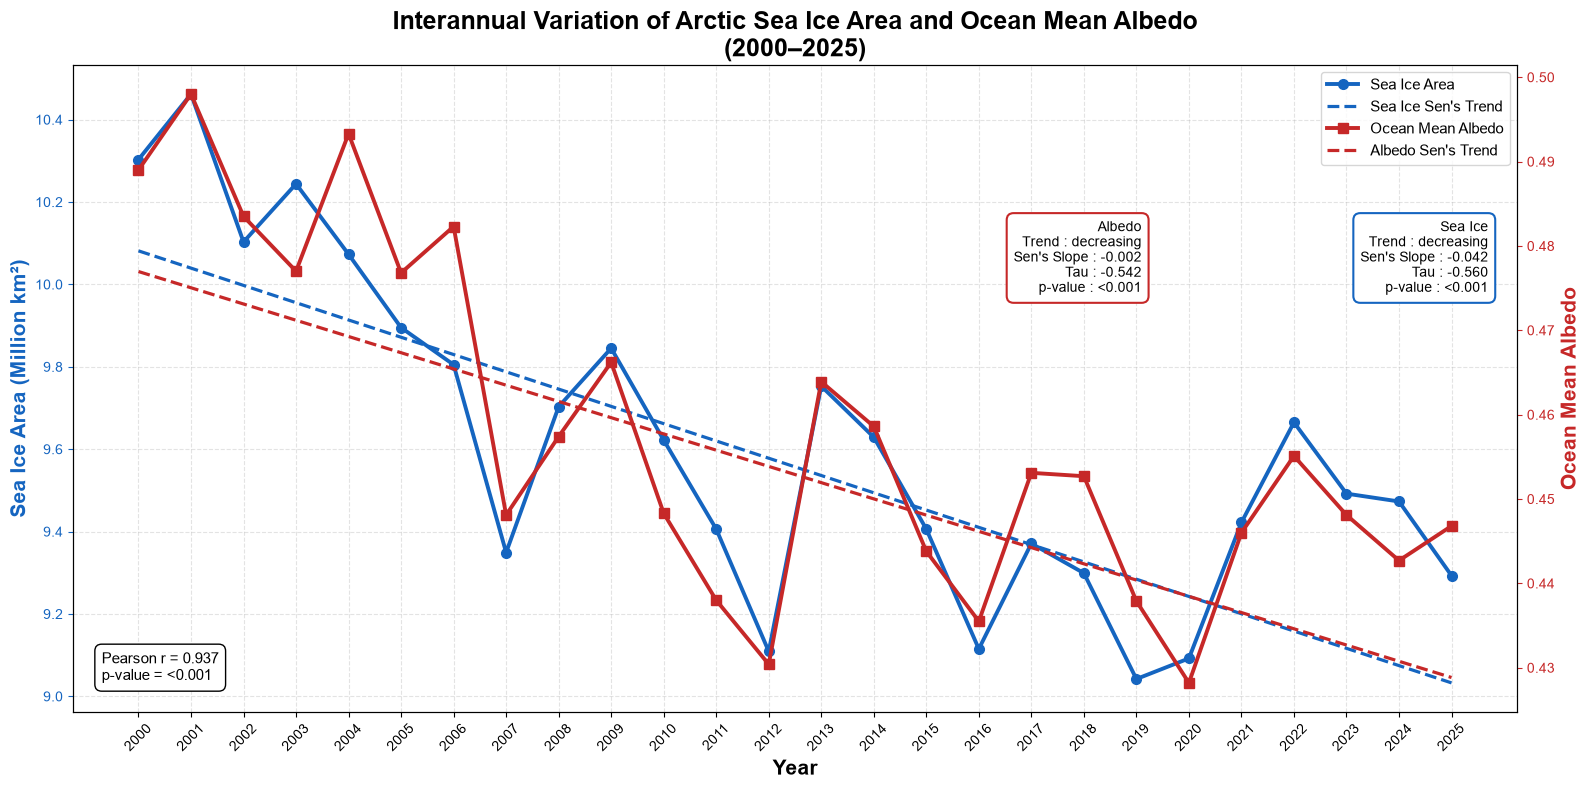

In [42]:
# ============================================================
# INTERANNUAL VARIATION OF SEA ICE AREA & OCEAN MEAN ALBEDO
# (ACTUAL VALUES)
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import pymannkendall as mk

# ============================================================
# FILTER YEARS
# ============================================================

start_year = 2000
end_year = 2025

df_plot = df[
    (df["Year"] >= start_year) &
    (df["Year"] <= end_year)
].copy()

# ============================================================
# VARIABLES
# ============================================================

# years = df_plot["Year"]

# sea = df_plot["Yearly Mean"]

# alb = df_plot["Ocean Mean Albedo"]

# ============================================================
# VARIABLES
# ============================================================

years = df_plot["Year"]

sea = df_plot["Sea Ice Area (Million km²)"]

alb = df_plot["Ocean Mean Albedo"]

# ============================================================
# PEARSON CORRELATION
# ============================================================

r, p_corr = pearsonr(sea, alb)

# ============================================================
# MANN-KENDALL TEST
# ============================================================

sea_result = mk.original_test(sea)

alb_result = mk.original_test(alb)

# ============================================================
# SEN'S TREND LINE
# ============================================================

index = np.arange(len(df_plot))

sea_sen = sea_result.intercept + sea_result.slope * index

alb_sen = alb_result.intercept + alb_result.slope * index

# ============================================================
# FIGURE
# ============================================================

plt.rcParams["font.family"] = "Arial"

fig, ax1 = plt.subplots(figsize=(16,8))

# ============================================================
# SEA ICE
# ============================================================

ax1.plot(
    years,
    sea,
    color="#1565C0",
    marker="o",
    linewidth=2.8,
    markersize=7,
    label="Sea Ice Area"
)

ax1.plot(
    years,
    sea_sen,
    "--",
    color="#1565C0",
    linewidth=2.3,
    label="Sea Ice Sen's Trend"
)

ax1.set_ylabel(
    "Sea Ice Area (Million km²)",
    fontsize=15,
    color="#1565C0",
    fontweight="bold"
)

ax1.tick_params(axis="y", colors="#1565C0")

# ============================================================
# ALBEDO
# ============================================================

ax2 = ax1.twinx()

ax2.plot(
    years,
    alb,
    color="#C62828",
    marker="s",
    linewidth=2.8,
    markersize=7,
    label="Ocean Mean Albedo"
)

ax2.plot(
    years,
    alb_sen,
    "--",
    color="#C62828",
    linewidth=2.3,
    label="Albedo Sen's Trend"
)

ax2.set_ylabel(
    "Ocean Mean Albedo",
    fontsize=15,
    color="#C62828",
    fontweight="bold"
)

ax2.tick_params(axis="y", colors="#C62828")

# ============================================================
# GRID
# ============================================================

ax1.grid(True, linestyle="--", alpha=0.35)

# ============================================================
# TITLE
# ============================================================

plt.title(
    "Interannual Variation of Arctic Sea Ice Area and Ocean Mean Albedo\n(2000–2025)",
    fontsize=18,
    fontweight="bold"
)

ax1.set_xlabel(
    "Year",
    fontsize=15,
    fontweight="bold"
)

# ============================================================
# PEARSON BOX
# ============================================================

corr_p = "<0.001" if p_corr < 0.001 else f"{p_corr:.4f}"

ax1.text(
    0.02,
    0.05,
    f"Pearson r = {r:.3f}\np-value = {corr_p}",
    transform=ax1.transAxes,
    fontsize=11,
    bbox=dict(
        facecolor="white",
        edgecolor="black",
        boxstyle="round,pad=0.45"
    )
)

# ============================================================
# SEA ICE BOX
# ============================================================

sea_p = "<0.001" if sea_result.p < 0.001 else f"{sea_result.p:.4f}"

# ax1.text(
#     0.98,
#     # 0.08,
#     0.76,

#     f"Sea Ice\n"
#     f"Trend : {sea_result.trend}\n"
#     f"Sen's Slope : {sea_result.slope:.3f}\n"
#     f"Tau : {sea_result.Tau:.3f}\n"
#     f"p-value : {sea_p}",
#     transform=ax1.transAxes,
#     fontsize=10,
#     ha="right",
#     va="bottom",
#     bbox=dict(
#         facecolor="white",
#         edgecolor="#1565C0",
#         linewidth=1.5,
#         boxstyle="round,pad=0.5"
#     )
# )

ax1.text(
    0.98,
    0.76,
    f"Sea Ice\n"
    f"Trend : {sea_result.trend}\n"
    f"Sen's Slope : {sea_result.slope:.3f}\n"
    f"Tau : {sea_result.Tau:.3f}\n"
    f"p-value : {sea_p}",
    transform=ax1.transAxes,
    fontsize=10,
    ha="right",
    va="top",
    bbox=dict(
        facecolor="white",
        edgecolor="#1565C0",
        linewidth=1.5,
        boxstyle="round,pad=0.5"
    )
)

# ============================================================
# ALBEDO BOX
# ============================================================

alb_p = "<0.001" if alb_result.p < 0.001 else f"{alb_result.p:.4f}"

# ax1.text(
#     0.73,
#     0.08,
#     f"Albedo\n"
#     f"Trend : {alb_result.trend}\n"
#     f"Sen's Slope : {alb_result.slope:.3f}\n"
#     f"Tau : {alb_result.Tau:.3f}\n"
#     f"p-value : {alb_p}",
#     transform=ax1.transAxes,
#     fontsize=10,
#     ha="center",
#     va="bottom",
#     bbox=dict(
#         facecolor="white",
#         edgecolor="#C62828",
#         linewidth=1.5,
#         boxstyle="round,pad=0.5"
#     )
# )

ax1.text(
    0.74,
    0.76,
    f"Albedo\n"
    f"Trend : {alb_result.trend}\n"
    f"Sen's Slope : {alb_result.slope:.3f}\n"
    f"Tau : {alb_result.Tau:.3f}\n"
    f"p-value : {alb_p}",
    transform=ax1.transAxes,
    fontsize=10,
    ha="right",
    va="top",
    bbox=dict(
        facecolor="white",
        edgecolor="#C62828",
        linewidth=1.5,
        boxstyle="round,pad=0.5"
    )
)

# ============================================================
# LEGEND
# ============================================================

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right",
    fontsize=11,
    frameon=True
)

# ============================================================
# X-TICKS
# ============================================================

ax1.set_xticks(years)
ax1.set_xticklabels(years, rotation=45)

plt.tight_layout()

# ============================================================
# SAVE
# ============================================================

plt.savefig(
    os.path.join(RESULTS, "Actual_SeaIce_Albedo_2000_2025.png"),
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(RESULTS, "Actual_SeaIce_Albedo_2000_2025.pdf"),
    bbox_inches="tight"
)

plt.show()

In [36]:
print(df_plot.columns)

Index(['Year', 'Sea Ice Area (Million km²)', 'Ocean Mean Albedo',
       'Sea Ice Deviation (%)', 'Albedo Deviation (%)'],
      dtype='str')


In [37]:
df_plot.head()

,Year,Sea Ice Area (Million km²),Ocean Mean Albedo,Sea Ice Deviation (%),Albedo Deviation (%)
0,2000,10.303,0.4890,7.163631,6.834052
1,2001,10.462,0.4980,8.817423,8.800323
2,2002,10.103,0.4835,5.083390,5.632442
3,2003,10.244,0.4770,6.549960,4.212357
4,2004,10.073,0.4933,4.771353,7.773492


In [40]:
print(df_plot.columns.tolist())

['Year', 'Sea Ice Area (Million km²)', 'Ocean Mean Albedo', 'Sea Ice Deviation (%)', 'Albedo Deviation (%)']
